In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv

load_dotenv()

True

In [5]:

llm = ChatGroq(model="openai/gpt-oss-120b")

In [6]:
llm.invoke("Hello, how are you?")

AIMessage(content='Hello! I’m doing great, thanks for asking. How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The user says "Hello, how are you?" It\'s a casual greeting. We respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 55, 'prompt_tokens': 77, 'total_tokens': 132, 'completion_time': 0.115545012, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.003798551, 'prompt_tokens_details': None, 'queue_time': 0.056216199, 'total_time': 0.119343563}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_d29d1d1418', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c12e3-08df-77f0-9e5c-037f31f7b6a3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 55, 'total_tokens': 132, 'output_token_details': {'reasoning': 28}})

In [14]:
# Create a State

class LLMState(TypedDict):
    question: str
    answer: str

In [15]:
# defining the node function
def llmqa(state: LLMState) -> LLMState:
    """Invoke LLM with prompt from state and store response back in state."""

    # Extract input text from the state 
    question = state['question']

    # Form the prompt for the model
    prompt = f"Answer the following question concisely:\n\n{question}"

    response = llm.invoke(prompt)
    
    state['answer'] = response.content
    return state

In [16]:
# our graph

graph = StateGraph(LLMState)

# add nodes

graph.add_node(
    "Generate Response",llmqa)

# define edges
graph.add_edge(START, "Generate Response")
graph.add_edge("Generate Response", END)

# compile the graph
workflow = graph.compile()

In [19]:
initial_state = {
    'question': "What is the capital of India?"}

final_state = workflow.invoke(initial_state)

print(final_state['answer'])

New Delhi.


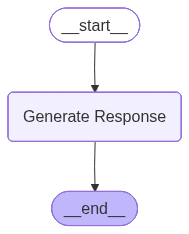

In [20]:
workflow